<a href="https://colab.research.google.com/github/marescost4/Mariane-David-Fillipy/blob/main/tarefa06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Bioestatística - atividade 6 - Regressão Linear Simples e Correlação de Pearson entre Comprimento e Massa Corporal de Artrópodes

- David Souza 16965966
- Mariane Santana 16890981
- Fillipy Leal 17097358

## 1 - Apresentação do conjunto de dados

O conjunto de dados utilizado nesta tarefa apresenta medidas corporais de artrópodes. Para isso, foram selecionadas duas variáveis numéricas: comprimento corporal em milímetros (mm), e massa corporal dos indivíduos em miligramas (mg).

O comprimento corporal será utilizado como variável explicativa (X), enquanto a massa corporal será utilizada como variável resposta (Y). E essa análise irá verificar a existência de uma associação linear entre o tamanho corporal e a massa dos indivíduos.

Para o conjunto de dados utilizados foram selcionadas 40 de 6608 observações presentes no estudo original.

###Fonte dos dados

SOHLSTRÖM, Esra H.; MARIAN, Lucas; BARNES, Andrew D.; et al. Dados de: Aplicação de regressões alométricas generalizadas para prever a massa corporal de artrópodes tropicais e temperados. Dryad, 2018. Publicado em: 7 dez. 2018. Disponível em: https://doi.org/10.5061/dryad.vk24fr1. Acesso em: 22 ago. 2026


Os dados foram originalmente disponibilizados por meio do repositório científico Dryad.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel('tarefa06.xlsx')


df.head (41)

,Live body mass (mg),Body length (mm)
0,152.30,14.60
1,4.15,4.90
2,0.25,2.56
3,8.71,3.46
4,16.17,4.14
5,3.16,2.57
6,5.47,2.76
7,51.86,6.04
8,4.39,3.13
9,4.57,2.74


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Live body mass (mg)  40 non-null     float64
 1   Body length (mm)     40 non-null     float64
dtypes: float64(2)
memory usage: 772.0 bytes


In [3]:
print("Número de observações:", len(df))

Número de observações: 40


In [4]:
dados_analise = df[['Live body mass (mg)', 'Body length (mm)']].copy()

# Renomeando as colunas para português

dados_analise.columns = ['massa', 'comprimento']

dados_analise.head(41)

,massa,comprimento
0,152.30,14.60
1,4.15,4.90
2,0.25,2.56
3,8.71,3.46
4,16.17,4.14
5,3.16,2.57
6,5.47,2.76
7,51.86,6.04
8,4.39,3.13
9,4.57,2.74


In [5]:
dados_analise.isnull().sum()

,0
massa,0
comprimento,0


## 2 - Gráfico de dispersão

O gráfico de dispersão é utilizado para visualizar a relação entre duas variáveis quantitativas. No grafíco o comprimento corporal será representado no eixo x e a massa corporal no eixo y. Cada ponto do gráfico representa um indivíduo do conjunto de dados. A disposição dos pontos permite observar se existe uma tendência de aumento ou diminuição da massa corporal conforme o comprimento corporal varia.

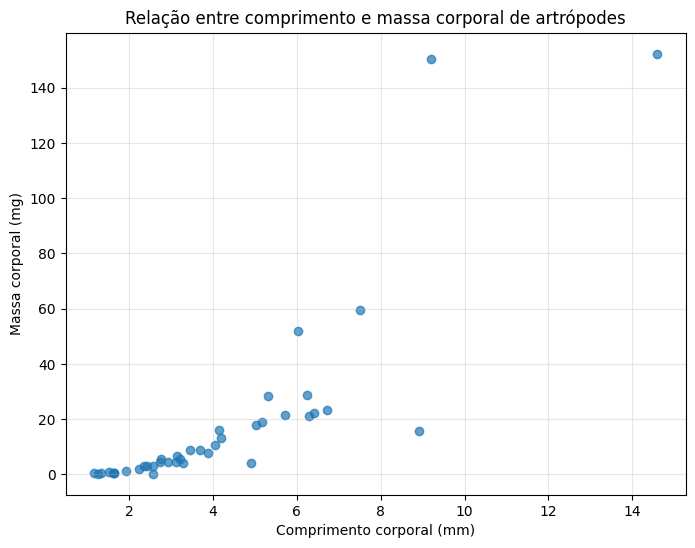

In [6]:
plt.figure(figsize=(8,6))

plt.scatter(dados_analise['comprimento'],dados_analise['massa'],alpha=0.7)

plt.xlabel('Comprimento corporal (mm)')
plt.ylabel('Massa corporal (mg)')
plt.title('Relação entre comprimento e massa corporal de artrópodes')

plt.grid(alpha=0.3) #adicionar grade

plt.show()

## 3 - Regressão linear simples, o que é?

A regressão linear simples é um método que descreve a relação entre duas variáveis que são quantitativas por meio de uma reta, onde haverá a variável independente/explicativa (X) que irá explicar ou influenciar a outra variável e a variável dependente/resposta (Y) que é a que queremos prever ou explicar.

Na representação o comprimento corporal é a variável independete/explicativa (X) e a massa corporal é a variável dependente/resposta (Y). A regressão permite estimar como a massa corporal varia em relação ao comprimento corporal dos indivíduos.

##4 - Calculo de coeficientes de regressão linear

In [7]:
x = dados_analise['comprimento']
y = dados_analise['massa']

b, a = np.polyfit(x, y, 1)

print("Intercepto (a):", a)
print("Coeficiente angular (b):", b)

Intercepto (a): -25.56616633866846
Coeficiente angular (b): 10.516510862163022


In [8]:
print(f"Intercepto (a) = {a:.4f}")
print(f"Coeficiente angular (b) = {b:.4f}")

Intercepto (a) = -25.5662
Coeficiente angular (b) = 10.5165


In [9]:
print(f"Massa = {a:.4f} + {b:.4f} (Comprimento)")

Massa = -25.5662 + 10.5165 (Comprimento)


##5 - Interpretação dos coeficientes da regressão

O intercepto (a) da reta foi −25,5662 mg representa o valor estimado da massa corporal quando o comprimento corporal é igual a zero (Essa situação não possui significado biológico real, pois um artrópode com comprimento igual a zero não existe, por isso o intercepto deve ser interpretado como um parâmetro matemático da reta).

O coeficiente angular (b) foi 10,5165 mg/mm e representa a variação esperada na massa corporal para cada aumento de 1 mm no comprimento corporal, espera-se um aumento médio de aproximadamente 10,52 mg na massa corporal (coeficiente angular positivo).

Consideramos para o coeficiente angular: se positivo, significa que existe uma tendência de aumento da massa corporal conforme o comprimento corporal aumenta e se negativo, significa uma tendência de redução da massa corporal com o aumento do comprimento.

##6 - Gráfico de dispersão com reta de regressão estimada.

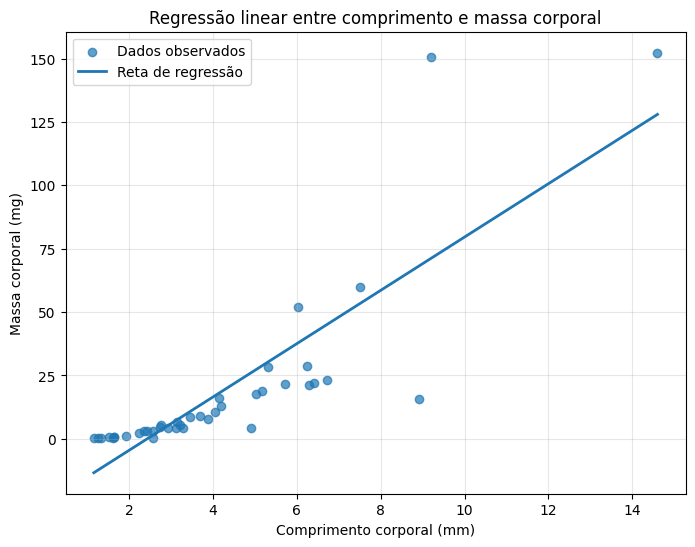

In [10]:
 # Adicionar a reta ao gráfico

# Calculando os valores estimados pela reta

y_pred = a + b * x

ordem = np.argsort(x)

plt.figure(figsize=(8,6))

# Dados observados
plt.scatter(x,y,alpha=0.7,label='Dados observados')

# Reta de regressão
plt.plot(x.iloc[ordem],y_pred.iloc[ordem],linewidth=2,label='Reta de regressão')

plt.xlabel('Comprimento corporal (mm)')
plt.ylabel('Massa corporal (mg)')
plt.title('Regressão linear entre comprimento e massa corporal')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

##7 - Correlação linear de Pearson, o que é?

A correlação linear de Pearson é uma medida que permite avaliar a direção e a intensidade da associação linear entre duas variáveis quantitativas, ou seja, se uma aumenta ou diminui, a outra acompanha.
O coeficiente de Pearson é representado pela letra r e varia entre -1 e +1. Sendo assim valores próximas próximos de +1 indicam uma forte associação linear positiva, valores próximos de -1 indicam uma forte associação linear negativa e valores próximos de 0 indicam pouca ou nenhuma associação linear.

Uma correlação positiva significa que maiores valores de uma variável tendem a estar associados a maiores valores da outra, uma correlação negativa significa que maiores valores de uma variável tendem a estar associados a valores menores da outra, já a correlação próxima de 0 não há evidencias de uma associação linear relevante

In [11]:
#Calcular Pearson
from scipy.stats import pearsonr
r, p_valor = pearsonr(x, y)

print(f"Coeficiente de Pearson (r): {r:.4f}")
print(f"Valor-p: {p_valor:.6f}")

Coeficiente de Pearson (r): 0.8375
Valor-p: 0.000000


In [12]:
print(f"Valor-p: {p_valor:.10f}")

Valor-p: 0.0000000000


## 8 - Interpretação do coeficiente de Pearson

O coeficiente de correlação de Pearson foi r = 0,8375. Como o coeficiente é positivo a correlação apresenta direção positiva. O valor de 0,8375 é relativamente próximo de +1, indicando uma correlação linear positiva entre o comprimento corporal e a massa corporal. No conjunto de dados analisado os indivíduos com maior comprimento corporal tendem a apresentar maior massa corporal. O valor-p obtido foi p < 0,001, indicando que a associação linear observada é estatisticamente significativa.

##9 - Direção da correlação

A correlação observada é positiva, pois o coeficiente de Pearson apresentou valor positivo (r = 0,8375). Isso significa que valores maiores de comprimento corporal tendem a estar associados a valores maiores de massa corporal.

Portanto, os resultados indicam uma tendência de aumento da massa corporal conforme o comprimento corporal aumenta.

##10 - Limitações da correlação de Pearson

Uma correlação igual ou próxima de zero indica ausência ou pouca evidência de uma relação linear, mas não significa necessariamente ausência de qualquer relação entre as variáveis Por exemplo, duas variáveis biológicas podem apresentar uma relação curva. Nesse caso, pode existir uma associação entre elas, mas o coeficiente de Pearson pode apresentar um valor baixo porque mede especificamente a relação linear.

Por isso, a interpretação do coeficiente de Pearson deve ser realizada juntamente com a observação do gráfico de dispersão.

##Conclusão

A análise realizada permitiu investigar a relação entre o comprimento corporal e a massa corporal de artrópodes utilizando 40 observações provenientes do conjunto de dados disponibilizado na plataforma Dryad.

A regressão linear simples apresentou um intercepto de −25,5662 mg e um coeficiente angular de 10,5165 mg/mm. O coeficiente angular positivo indica que, de acordo com o modelo, aumentos no comprimento corporal estão associados a aumentos na massa corporal. Especificamente, para cada aumento de 1 mm no comprimento, estima-se um aumento médio de aproximadamente 10,52 mg na massa corporal.

A correlação de Pearson apresentou r = 0,8375, indicando uma correlação linear positiva forte entre as duas variáveis. O valor-p foi p < 0,001, indicando que a associação linear observada é estatisticamente significativa.

Assim, os resultados indicam que indivíduos com maior comprimento corporal tendem a apresentar maior massa corporal nesse conjunto de dados. A regressão linear simples e a correlação de Pearson foram úteis para quantificar e interpretar essa associação entre duas características morfológicas dos artrópodes.

Apesar disso, é importante destacar que a correlação de Pearson avalia especificamente relações lineares e que uma associação estatística não significa necessariamente uma relação de causa e efeito.